In [1]:
!pip install pandas

In [2]:
!pip install scikit-learn

In [3]:
!pip install keras

In [4]:
!pip install tensorflow
!pip install pydot graphviz

In [5]:
!pip install pydot

In [6]:
!pip install lightgbm

In [7]:
!pip install matplotlib

In [8]:
!pip install seaborn

In [9]:
# Librerias
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from keras.utils import plot_model
import keras
from keras.models import Sequential # Arquitectura
from keras.layers import Dense      # capa de la red
from keras.utils import plot_model
import gc

In [10]:
# Cargar los datos
data_ord = pd.read_csv("data_ord.csv")
cardlist = pd.read_csv("cardlist.csv")

In [11]:
# Explorar la dimensionalidad
print("Dimensiones del dataset cardlist:", cardlist.shape)
print("Dimensiones del dataset data_ord:", data_ord.shape)

Dimensiones del dataset cardlist: (106, 3)
Dimensiones del dataset data_ord: (718886, 20)


In [12]:
# Verificar las características de cardlist
print("Información de cardlist:")
print(cardlist.info())
print("\nDescripción de cardlist:")
print(cardlist.describe())

Información de cardlist:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  106 non-null    int64 
 1   id          106 non-null    int64 
 2   card        106 non-null    object
dtypes: int64(2), object(1)
memory usage: 2.6+ KB
None

Descripción de cardlist:
       Unnamed: 0          id
count  106.000000  106.000000
mean    52.500000   52.500000
std     30.743563   30.743563
min      0.000000    0.000000
25%     26.250000   26.250000
50%     52.500000   52.500000
75%     78.750000   78.750000
max    105.000000  105.000000


In [13]:
# Verificar las características de data_ord
print("Información de data_ord:")
print(data_ord.info())
print("\nDescripción de data_ord:")
print(data_ord.describe())

Información de data_ord:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718886 entries, 0 to 718885
Data columns (total 20 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  718886 non-null  int64
 1   p1card1     718886 non-null  int64
 2   p1card2     718886 non-null  int64
 3   p1card3     718886 non-null  int64
 4   p1card4     718886 non-null  int64
 5   p1card5     718886 non-null  int64
 6   p1card6     718886 non-null  int64
 7   p1card7     718886 non-null  int64
 8   p1card8     718886 non-null  int64
 9   p2card1     718886 non-null  int64
 10  p2card2     718886 non-null  int64
 11  p2card3     718886 non-null  int64
 12  p2card4     718886 non-null  int64
 13  p2card5     718886 non-null  int64
 14  p2card6     718886 non-null  int64
 15  p2card7     718886 non-null  int64
 16  p2card8     718886 non-null  int64
 17  p1trophies  718886 non-null  int64
 18  p2trophies  718886 non-null  int64
 19  outcome     718886 

In [14]:
# Verificar valores nulos en cardlist
print("Valores nulos en cardlist:")
print(cardlist.isnull().sum())

Valores nulos en cardlist:
Unnamed: 0    0
id            0
card          0
dtype: int64


In [15]:
# Verificar valores nulos en data_ord
print("\nValores nulos en data_ord:")
print(data_ord.isnull().sum())


Valores nulos en data_ord:
Unnamed: 0    0
p1card1       0
p1card2       0
p1card3       0
p1card4       0
p1card5       0
p1card6       0
p1card7       0
p1card8       0
p2card1       0
p2card2       0
p2card3       0
p2card4       0
p2card5       0
p2card6       0
p2card7       0
p2card8       0
p1trophies    0
p2trophies    0
outcome       0
dtype: int64


In [16]:
# Contar el número de ocurrencias de cada clase en la columna 'outcome'
class_counts = data_ord['outcome'].value_counts()

# Conteo de clases
print(f'Conteo de clases en la columna "outcome" de data_ord:\n{class_counts}')

# Proporción de cada clase
class_proportions = data_ord['outcome'].value_counts(normalize=True)
print(f'Proporción de clases en la columna "outcome de data_ord":\n{class_proportions}')

Conteo de clases en la columna "outcome" de data_ord:
outcome
1    400574
0    318312
Name: count, dtype: int64
Proporción de clases en la columna "outcome de data_ord":
outcome
1    0.557215
0    0.442785
Name: proportion, dtype: float64


In [17]:
# Aplicar dummización a las columnas de cartas
data_ord_dummified = pd.get_dummies(data_ord, columns=[
    'p1card1', 'p1card2', 'p1card3', 'p1card4', 'p1card5',
    'p1card6', 'p1card7', 'p1card8', 'p2card1', 'p2card2',
    'p2card3', 'p2card4', 'p2card5', 'p2card6', 'p2card7',
    'p2card8'
],drop_first = True)

In [18]:
data_ord_dummified.head()

,Unnamed: 0,p1trophies,p2trophies,outcome,p1card1_1,p1card1_2,p1card1_3,p1card1_4,p1card1_5,p1card1_6,...,p2card8_96,p2card8_97,p2card8_98,p2card8_99,p2card8_100,p2card8_101,p2card8_102,p2card8_103,p2card8_104,p2card8_105
0,0,7578,7597,1,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,1,7548,7551,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2,7518,7523,1,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,3,7485,7523,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,4,7126,7114,1,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [19]:
# Eliminar 'outcome' (variable a predecir)
X = data_ord_dummified.drop('outcome', axis=1)  # Variables independientes
y = data_ord_dummified['outcome']  # Variable dependiente

In [20]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [21]:
# Normalizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Ajustar PCA con 34 componentes
pca = PCA(34)
pca.fit(X_train_scaled)

PCA(n_components=34)

In [23]:
# Mostrar varianza explicada por cada componente
print(f'Varianza explicada por cada componente: {pca.explained_variance_ratio_}')

# Mostrar varianza explicada acumulada
print(f'Varianza explicada acumulada: {pca.explained_variance_ratio_.cumsum()}')

Varianza explicada por cada componente: [0.00407458 0.00377976 0.00366157 0.00357715 0.00353532 0.00343554
 0.00335601 0.00330967 0.00312991 0.00311677 0.00307886 0.00292774
 0.00286997 0.00279339 0.00275946 0.0027425  0.00268777 0.00267565
 0.00256382 0.00254997 0.00249447 0.00247869 0.00244506 0.00238356
 0.0023754  0.00229743 0.00221784 0.00221377 0.00218033 0.00213015
 0.00212342 0.00211331 0.0020831  0.00202991]
Varianza explicada acumulada: [0.00407458 0.00785434 0.01151591 0.01509305 0.01862837 0.02206391
 0.02541992 0.02872959 0.0318595  0.03497627 0.03805513 0.04098287
 0.04385285 0.04664623 0.04940569 0.0521482  0.05483596 0.05751161
 0.06007543 0.0626254  0.06511987 0.06759856 0.07004362 0.07242718
 0.07480258 0.07710001 0.07931785 0.08153162 0.08371195 0.0858421
 0.08796552 0.09007883 0.09216194 0.09419185]


In [24]:
X_train_pca_final = pca.fit_transform(X_train_scaled)
X_test_pca_final = pca.transform(X_test_scaled)

In [25]:
# Red neuronal tipo feed fordward
# Crear el modelo de red neuronal
red = Sequential()

In [26]:
capa_1 = Dense(28, input_dim=34, use_bias=True, activation='relu')  # Capa de entrada
capa_2 = Dense(14, activation='relu')   
capa_3 = Dense(1, activation='sigmoid')  # Capa de salida

C:\Users\Natalia.LAPTOP-SRNRNE03\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# Añadir las capas al modelo
red.add(capa_1)
red.add(capa_2)
red.add(capa_3)

In [28]:
# Resumen del modelo
red.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 28)                  │             980 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 14)                  │             406 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              15 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,401 (5.47 KB)

 Trainable params: 1,401 (5.47 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Compilar el modelo
from keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)
red.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
import numpy as np
np.shape(X_train)

(503220, 1426)

In [31]:
# Entrenar el modelo con los datos
history = red.fit(X_train_pca_final, y_train, epochs=25, batch_size=64, validation_data=(X_test_pca_final,y_test))

Epoch 1/25
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - accuracy: 0.5529 - loss: 0.6883 - val_accuracy: 0.5626 - val_loss: 0.6820
Epoch 2/25
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.5633 - loss: 0.6815 - val_accuracy: 0.5657 - val_loss: 0.6810
Epoch 3/25
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.5675 - loss: 0.6800 - val_accuracy: 0.5676 - val_loss: 0.6804
Epoch 4/25
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.5672 - loss: 0.6799 - val_accuracy: 0.5663 - val_loss: 0.6809
Epoch 5/25
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5683 - loss: 0.6795 - val_accuracy: 0.5686 - val_loss: 0.6799
Epoch 6/25
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.5686 - loss: 0.6790 - val_accuracy: 0.5673 - val_loss: 0.6801
Epoch 7/25
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.5704 - loss: 0.6788 - val_accuracy: 0.5693 - val_loss: 0.6795
Epoch 8/25
7863/7863 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.5718 - loss: 0

In [32]:
y_pred=red.predict(X_test_pca_final)
y_pred

6740/6740 ━━━━━━━━━━━━━━━━━━━━ 7s 964us/step


array([[0.5801225 ],
       [0.46127328],
       [0.5009613 ],
       ...,
       [0.48616272],
       [0.58426917],
       [0.6117227 ]], dtype=float32)

In [33]:
y_pred = np.round(y_pred)
y_pred

array([[1.],
       [0.],
       [1.],
       ...,
       [0.],
       [1.],
       [1.]], dtype=float32)

In [34]:
# Métricas de entrenamiento y validación del historial
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

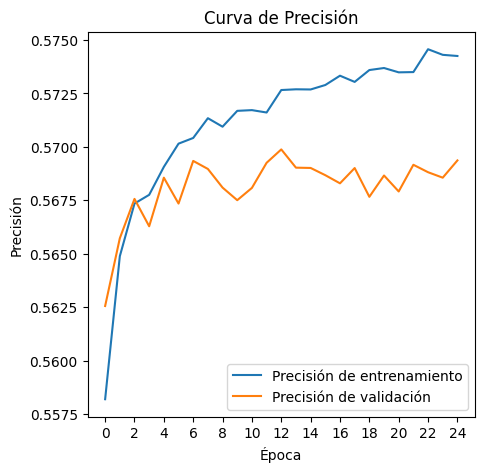

In [35]:
#Curva de Precisión
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.plot(train_acc, label='Precisión de entrenamiento')
plt.plot(val_acc, label='Precisión de validación')
plt.title('Curva de Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.xticks(range(0, len(train_acc), 2))
plt.show()

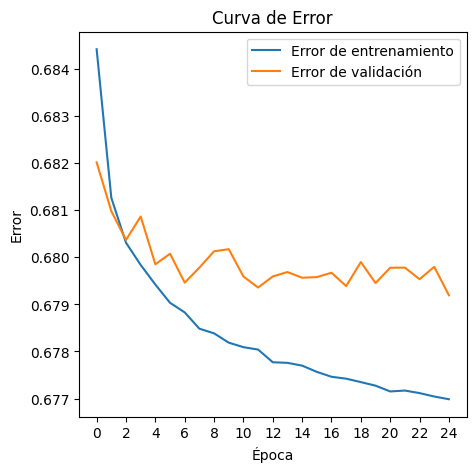

In [36]:
#Curva de Error
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
plt.plot(train_loss, label='Error de entrenamiento')
plt.plot(val_loss, label='Error de validación')
plt.title('Curva de Error')
plt.xlabel('Época')
plt.ylabel('Error')
plt.legend()
plt.xticks(range(0, len(train_acc), 2))
plt.show()

In [37]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[ 18578  76856]
 [ 16017 104215]]


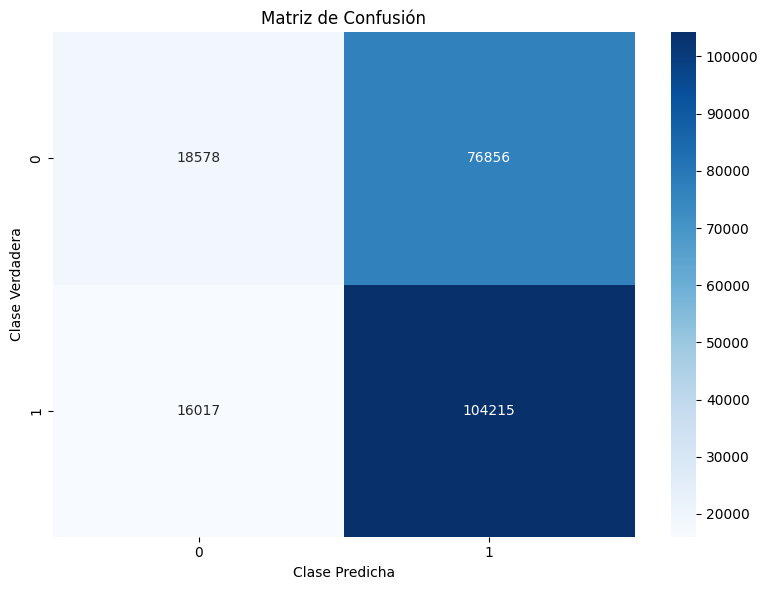

In [38]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cbar=True, cmap="Blues", fmt='g')

# Añadir títulos y etiquetas
plt.title("Matriz de Confusión")
plt.ylabel("Clase Verdadera")
plt.xlabel("Clase Predicha")
plt.tight_layout()
plt.show()

In [39]:
# Evaluar el modelo en los datos de prueba
score = red.evaluate(X_train_pca_final, y_train)
print("\n%s: %.2f%%" % (red.metrics_names[1], score[1]*100))

15726/15726 ━━━━━━━━━━━━━━━━━━━━ 12s 791us/step - accuracy: 0.5751 - loss: 0.6763

compile_metrics: 57.55%


In [40]:
# Evaluar el modelo en los datos de prueba
score = red.evaluate(X_test_pca_final, y_test)
print("\n%s: %.2f%%" % (red.metrics_names[1], score[1]*100))

6740/6740 ━━━━━━━━━━━━━━━━━━━━ 6s 830us/step - accuracy: 0.5692 - loss: 0.6791

compile_metrics: 56.94%


In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

         0.0       0.19      0.54      0.29     34595
         1.0       0.87      0.58      0.69    181071

    accuracy                           0.57    215666
   macro avg       0.53      0.56      0.49    215666
weighted avg       0.76      0.57      0.63    215666



6740/6740 ━━━━━━━━━━━━━━━━━━━━ 6s 902us/step


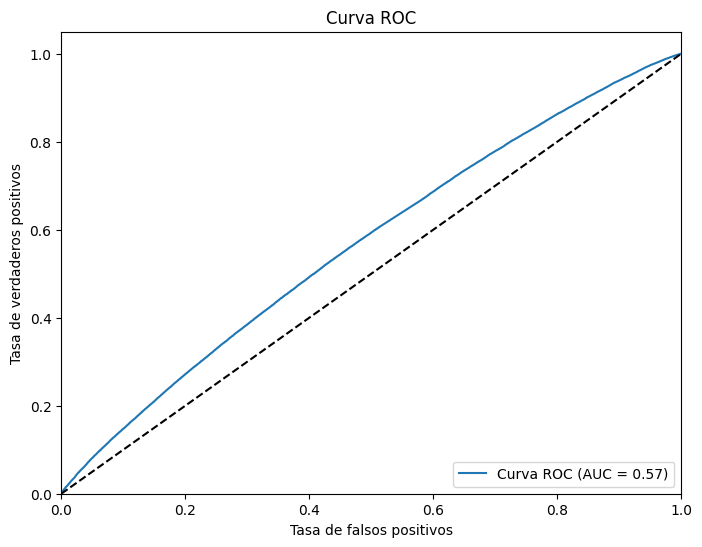

              precision    recall  f1-score   support

           0       0.57      0.49      0.53    111784
           1       0.52      0.61      0.56    103882

    accuracy                           0.54    215666
   macro avg       0.55      0.55      0.54    215666
weighted avg       0.55      0.54      0.54    215666



In [42]:
# Curva ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# Paso 1: Realizar predicciones con tu modelo entrenado
y_pred_proba = red.predict(X_test_pca_final)

# Paso 2: Ajustar las predicciones a un solo valor utilizando un umbral
y_pred = (y_pred_proba > 0.56).astype(int)

# Paso 3: Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Paso 4: Calcular el área bajo la curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_proba)

# Paso 5: Trazar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Curva ROC (AUC = {:.2f})'.format(auc))
plt.plot([0, 1], [0, 1], 'k--')  # Línea de referencia para un clasificador aleatorio
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

# Paso 6: Imprimir el informe de clasificación
print(classification_report(y_pred, y_test))

In [44]:
# Crear el modelo de Regresión Logística con el solver por defecto
modelo_logit = LogisticRegression(class_weight='balanced')

In [45]:
# Entrenar el modelo
modelo_logit.fit(X_train_pca_final, y_train)

LogisticRegression(class_weight='balanced')

In [46]:
y_proba = modelo_logit.predict_proba(X_test_pca_final)[:, 1]  # Probabilidad de la clase positiva
umbral = 0.4  
y_pred_custom = (y_proba >= umbral).astype(int)

In [47]:
# Evaluar el modelo
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_custom))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_custom))

Matriz de Confusión:
[[   262  95172]
 [   243 119989]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.52      0.00      0.01     95434
           1       0.56      1.00      0.72    120232

    accuracy                           0.56    215666
   macro avg       0.54      0.50      0.36    215666
weighted avg       0.54      0.56      0.40    215666



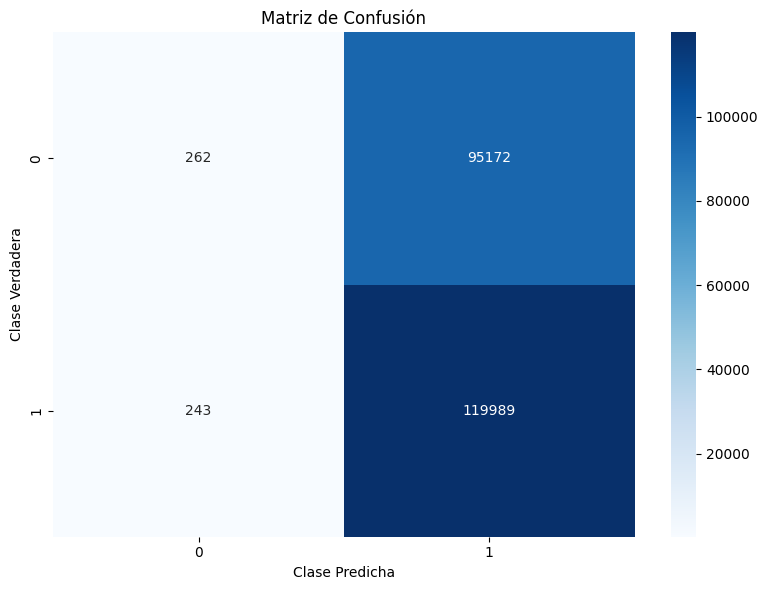

In [49]:
cm = confusion_matrix(y_test, y_pred_custom)

# Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cbar=True, cmap="Blues", fmt='g')

# Añadir títulos y etiquetas
plt.title("Matriz de Confusión")
plt.ylabel("Clase Verdadera")
plt.xlabel("Clase Predicha")
plt.tight_layout()
plt.show()

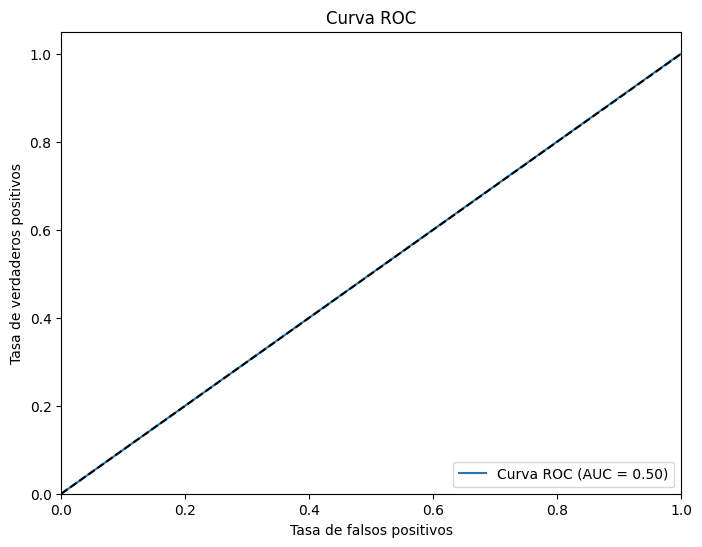

In [50]:
# Paso 3: Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_custom)

# Paso 4: Calcular el área bajo la curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_custom)

# Paso 5: Trazar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Curva ROC (AUC = {:.2f})'.format(auc))
plt.plot([0, 1], [0, 1], 'k--')  # Línea de referencia para un clasificador aleatorio
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

In [31]:
# Tercer modelo
# Tomar una muestra del 10% de los datos para reducir el uso de memoria
data_sample = data_ord_dummified.sample(frac=0.1, random_state=42)

# Definir las variables independientes (X) y la variable dependiente (y)
X = data_sample.drop('outcome', axis=1)  # Reemplaza 'outcome' con la columna objetivo
y = data_sample['outcome']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Liberar memoria de las variables no necesarias y forzar la recolección de basura
del data_sample, X, y
gc.collect()

# Imputación de valores faltantes y escalado
imputer = SimpleImputer(strategy='mean')  # Cambiar estrategia si es necesario (e.g., 'median', 'most_frequent')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelo de selección de características usando LightGBM
selector = SelectFromModel(estimator=lgb.LGBMClassifier(random_state=42), threshold='median')
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Liberar memoria de objetos intermedios
del imputer, scaler, selector
gc.collect()

# Entrenar LightGBM
model = lgb.LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

# Liberar memoria de los datos de entrenamiento
del X_train, y_train
gc.collect()

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))
print(f"Precisión: {accuracy_score(y_test, y_pred)}")

# Liberar memoria de los datos de prueba
del X_test, y_test, y_pred, model
gc.collect()


[LightGBM] [Info] Number of positive: 28074, number of negative: 22248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3723
[LightGBM] [Info] Number of data points in the train set: 50322, number of used features: 989
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.557887 -> initscore=0.232592
[LightGBM] [Info] Start training from score 0.232592


C:\Users\DIEGO CABALLERO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
C:\Users\DIEGO CABALLERO\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 28074, number of negative: 22248
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3723
[LightGBM] [Info] Number of data points in the train set: 50322, number of used features: 989
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.557887 -> initscore=0.232592
[LightGBM] [Info] Start training from score 0.232592
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.51      0.18      0.26      9513
           1       0.57      0.87      0.69     12054

    accuracy                           0.56     21567
   macro avg       0.54      0.52      0.48     21567
weighted avg       0.55      0.56      0.50     21567

Precisión: 0.5634070570779431


4

In [41]:
model = lgb.LGBMClassifier(random_state=42, n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 320459, number of negative: 254649
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 575108, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.557215 -> initscore=0.229868
[LightGBM] [Info] Start training from score 0.229868


LGBMClassifier(random_state=42)

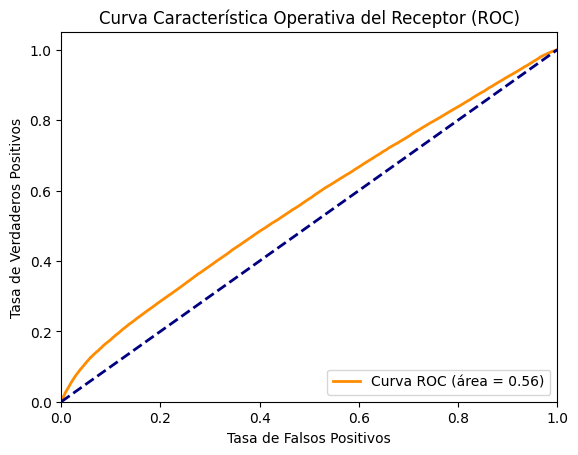

AUC: 0.5613311058715019


In [45]:
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilidades de la clase positiva

# Calcular la curva ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (área = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend(loc="lower right")
plt.show()

# Imprimir el AUC
print(f"AUC: {roc_auc}")